In [1]:
import numpy as np
import librosa
from scipy.signal import butter, lfilter

# --- 1. FILTRO BUTTERWORTH DE SEGUNDO ORDEN (Coincide con tu H(z)) ---
def butter_highpass_filter(data, cutoff=80, fs=22050):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    # order=2 para que sea de segundo orden como dice tu documento
    b, a = butter(2, normal_cutoff, btype='high', analog=False)
    # lfilter implementa la función de transferencia H(z) que pusiste en la imagen
    y = lfilter(b, a, data)
    return y

# --- 2. DETECTOR DE ACTIVIDAD VOCAL (VAD) ---
def apply_vad(data, sr, top_db=25):
    # Segmenta descartando silencios por trama (clasificación binaria de energía)
    intervals = librosa.effects.split(data, top_db=top_db)
    if len(intervals) == 0:
        return np.zeros(int(2.5 * sr))
    vad_audio = np.concatenate([data[start:end] for start, end in intervals])
    return vad_audio

# --- 3. NORMALIZACIÓN MIN-MAX [0, 1] ---
def normalize_signal(data):
    # Implementa exactamente la fórmula x_hat[n] de tu imagen
    min_val = np.min(data)
    max_val = np.max(data)
    if max_val - min_val == 0:
        return data
    return (data - min_val) / (max_val - min_val)

# --- PIPELINE COMPLETO (COMO ESTÁ EN TU TEXTO) ---
def preprocess_vocalink_pipeline(path):
    # A. Adquisición y remuestreo a 22,050 Hz
    data, sr = librosa.load(path, sr=22050, duration=None)
    
    # B. Filtrado Butterworth de segundo orden (fc = 80 Hz)
    data = butter_highpass_filter(data, cutoff=80, fs=sr)
    
    # C. VAD (Detección de Actividad Vocal)
    data = apply_vad(data, sr)
    
    # D. Normalización al rango [0, 1]
    data = normalize_signal(data)
    
    # E. Ajuste a duración fija de 2.5 s (para la entrada de la CNN)
    target_length = int(2.5 * sr)
    if len(data) < target_length:
        data = np.pad(data, (0, target_length - len(data)), mode='constant')
    else:
        data = data[:target_length]
        
    return data, sr

/var/folders/6d/kjyx68nn3gsf95x0747lnp500000gn/T/ipykernel_85840/3462529593.py:8: UserWarning: PySoundFile failed. Trying audioread instead.
  raw_audio, sr = librosa.load(path, sr=22050)
/opt/anaconda3/lib/python3.12/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


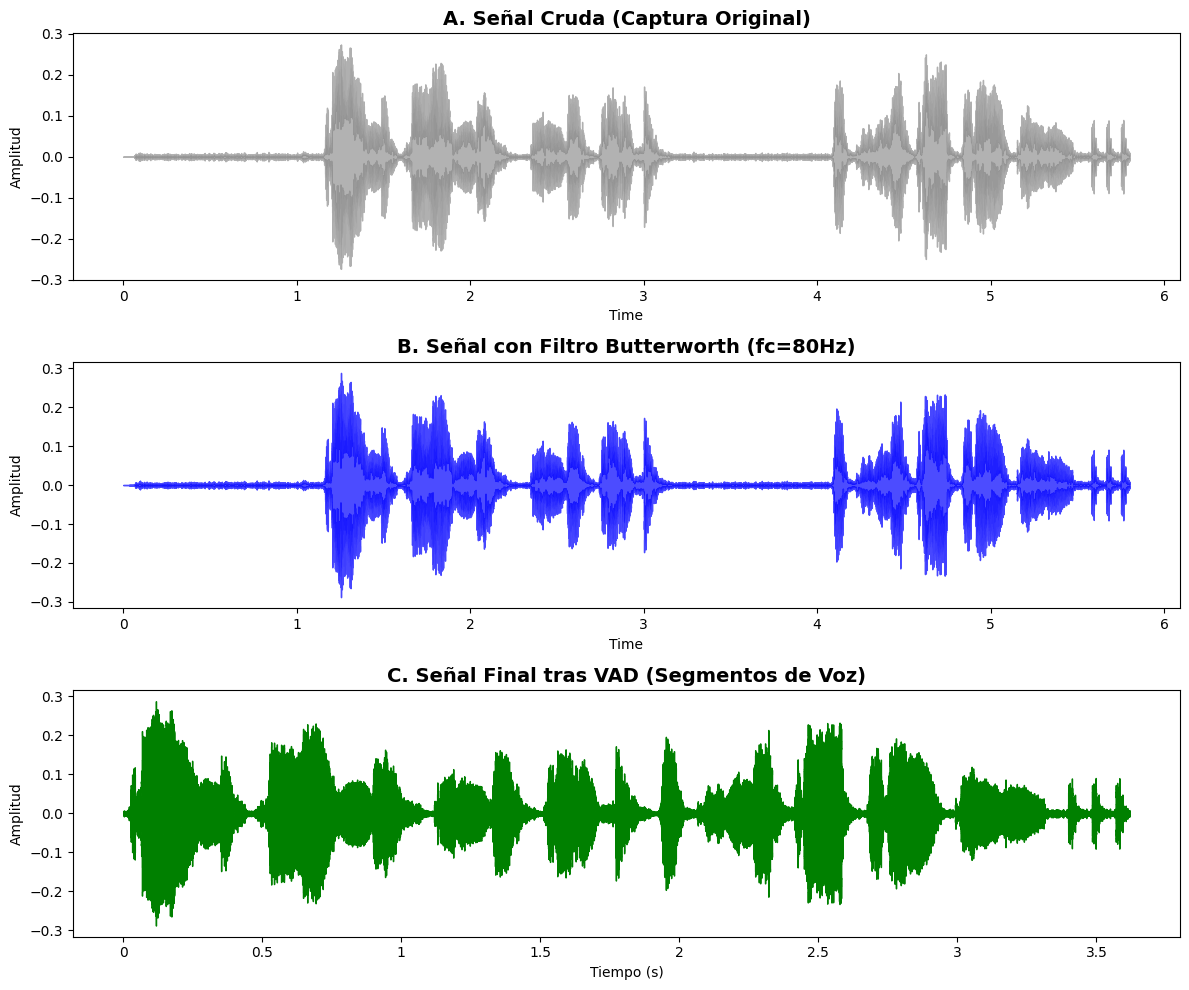

Porcentaje de audio descartado (silencio/ruido): 37.61%


In [3]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

# 1. Cargar el audio "crudo"
path = "/Users/Catalina/IBIO/2026-1/PD2/Modelo final/Speech-Emotion-Recognition-with-MFCC-main/audio prueba.m4a" 
raw_audio, sr = librosa.load(path, sr=22050)

# 2. Aplicar Filtro Butterworth (Pipeline Iteración 3)
# (Usando la función que definimos antes)
filtered_audio = butter_highpass_filter(raw_audio, cutoff=80, fs=sr)

# 3. Aplicar VAD (Recorte de silencios)
# top_db=20 es sensible; ajusta si el ruido es muy fuerte
intervals = librosa.effects.split(filtered_audio, top_db=25)
vad_audio = np.concatenate([filtered_audio[start:end] for start, end in intervals])

# --- GENERAR LA GRÁFICA PARA EL ANEXO 17 ---
plt.figure(figsize=(12, 10))

# Top: Audio Crudo
plt.subplot(3, 1, 1)
librosa.display.waveshow(raw_audio, sr=sr, color='gray', alpha=0.6)
plt.title('A. Señal Cruda (Captura Original)', fontsize=14, fontweight='bold')
plt.ylabel('Amplitud')

# Middle: Audio Filtrado
plt.subplot(3, 1, 2)
librosa.display.waveshow(filtered_audio, sr=sr, color='blue', alpha=0.7)
plt.title('B. Señal con Filtro Butterworth (fc=80Hz)', fontsize=14, fontweight='bold')
plt.ylabel('Amplitud')

# Bottom: Audio con VAD (Lo que entra a la CNN)
plt.subplot(3, 1, 3)
librosa.display.waveshow(vad_audio, sr=sr, color='green')
plt.title('C. Señal Final tras VAD (Segmentos de Voz)', fontsize=14, fontweight='bold')
plt.ylabel('Amplitud')
plt.xlabel('Tiempo (s)')

plt.tight_layout()
plt.savefig("anexo_17_comparativa.png", dpi=300)
plt.show()

# Dato para tu tabla de MVP
reduccion = (1 - (len(vad_audio)/len(raw_audio))) * 100
print(f"Porcentaje de audio descartado (silencio/ruido): {reduccion:.2f}%")